## Nel dataframe con le colonne numeriche ci si può porre altre domande, quindi si considera ogni coppia possibile tra tutte le colonne. Fare una figura con tanti grafici una matrice di grafici

Considerare le variabili engine_power, age_in_days, km, lat, price (5 totali)

Creare una figura con 5 x 5 grafici: i grafici devono mostrare come una variabile dipende da un'altra variabile, secondo tutte le possibili combinazioni 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
#Leggo il file csv
data = pd.read_csv("Used_fiat_500_in_Italy_dataset.csv")

In [4]:
# Lista di nomi delle colonne
nomi_colonne = ["engine_power", "age_in_days", "km", "lat", "price"]

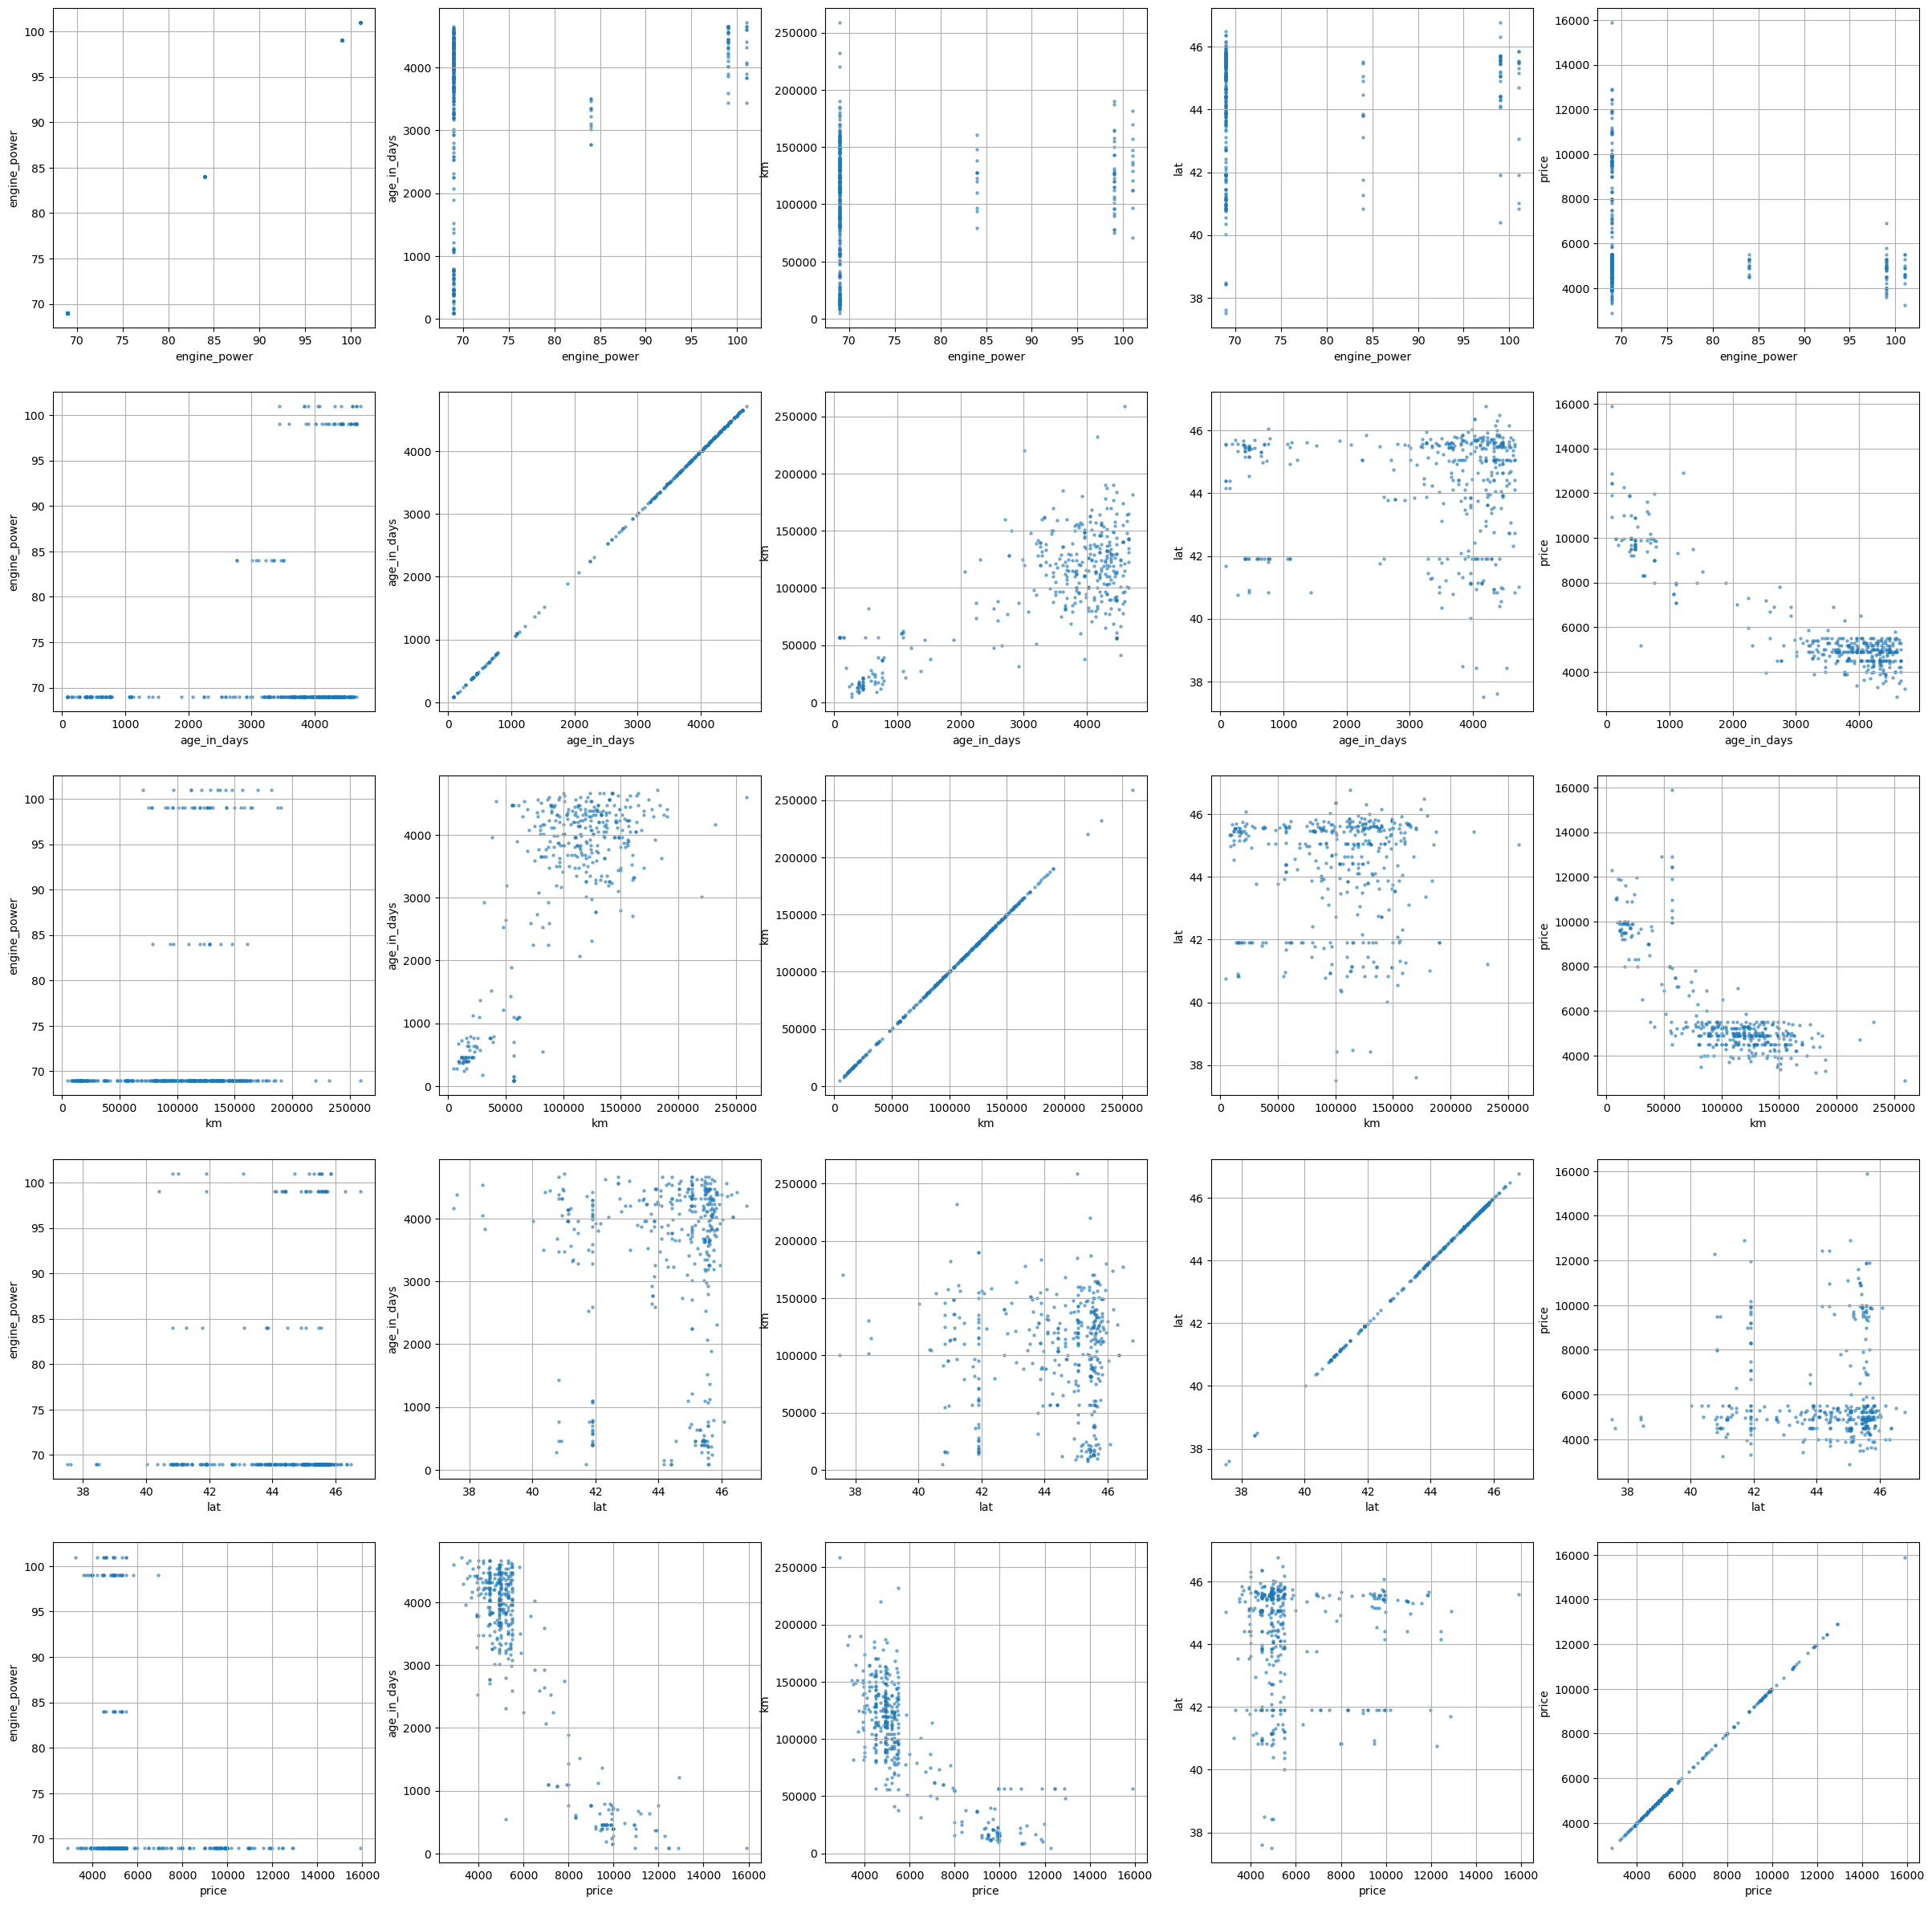

In [5]:
#Per avere tutti i grafici! con le due variabili la rielaborazione non mi richiede la filtrazione tosta con il doppio data data[data..

fig, axs = plt.subplots(nrows=5, ncols=5, figsize = (30, 30))
for i, var1 in enumerate(nomi_colonne):
    for j, var2  in enumerate(nomi_colonne):
        array1 = data[var1].to_numpy()
        array2 = data[var2].to_numpy()
        axs[i, j].scatter(array1, array2, alpha = 0.5, s = 5)
        axs[i, j].set_xlabel(var1)
        axs[i, j].set_ylabel(var2)
        axs[i, j].grid()
plt.show()

## Compito: 
* Scrivere cosa posso dedurre da tutti questi grafici con una frase
* Utilizzare un terzo ciclo for sui modelli per distinguere i diversi modelli usando il colore, sia negli scatter che negli hist
* Ricordo: il dataframe è di macchine in vendita!

### Per gestire la diagonale di grafici con variabili uguali mettiamo i numeri di casi e facciamo histogrammi per dedurre nuove informazioni

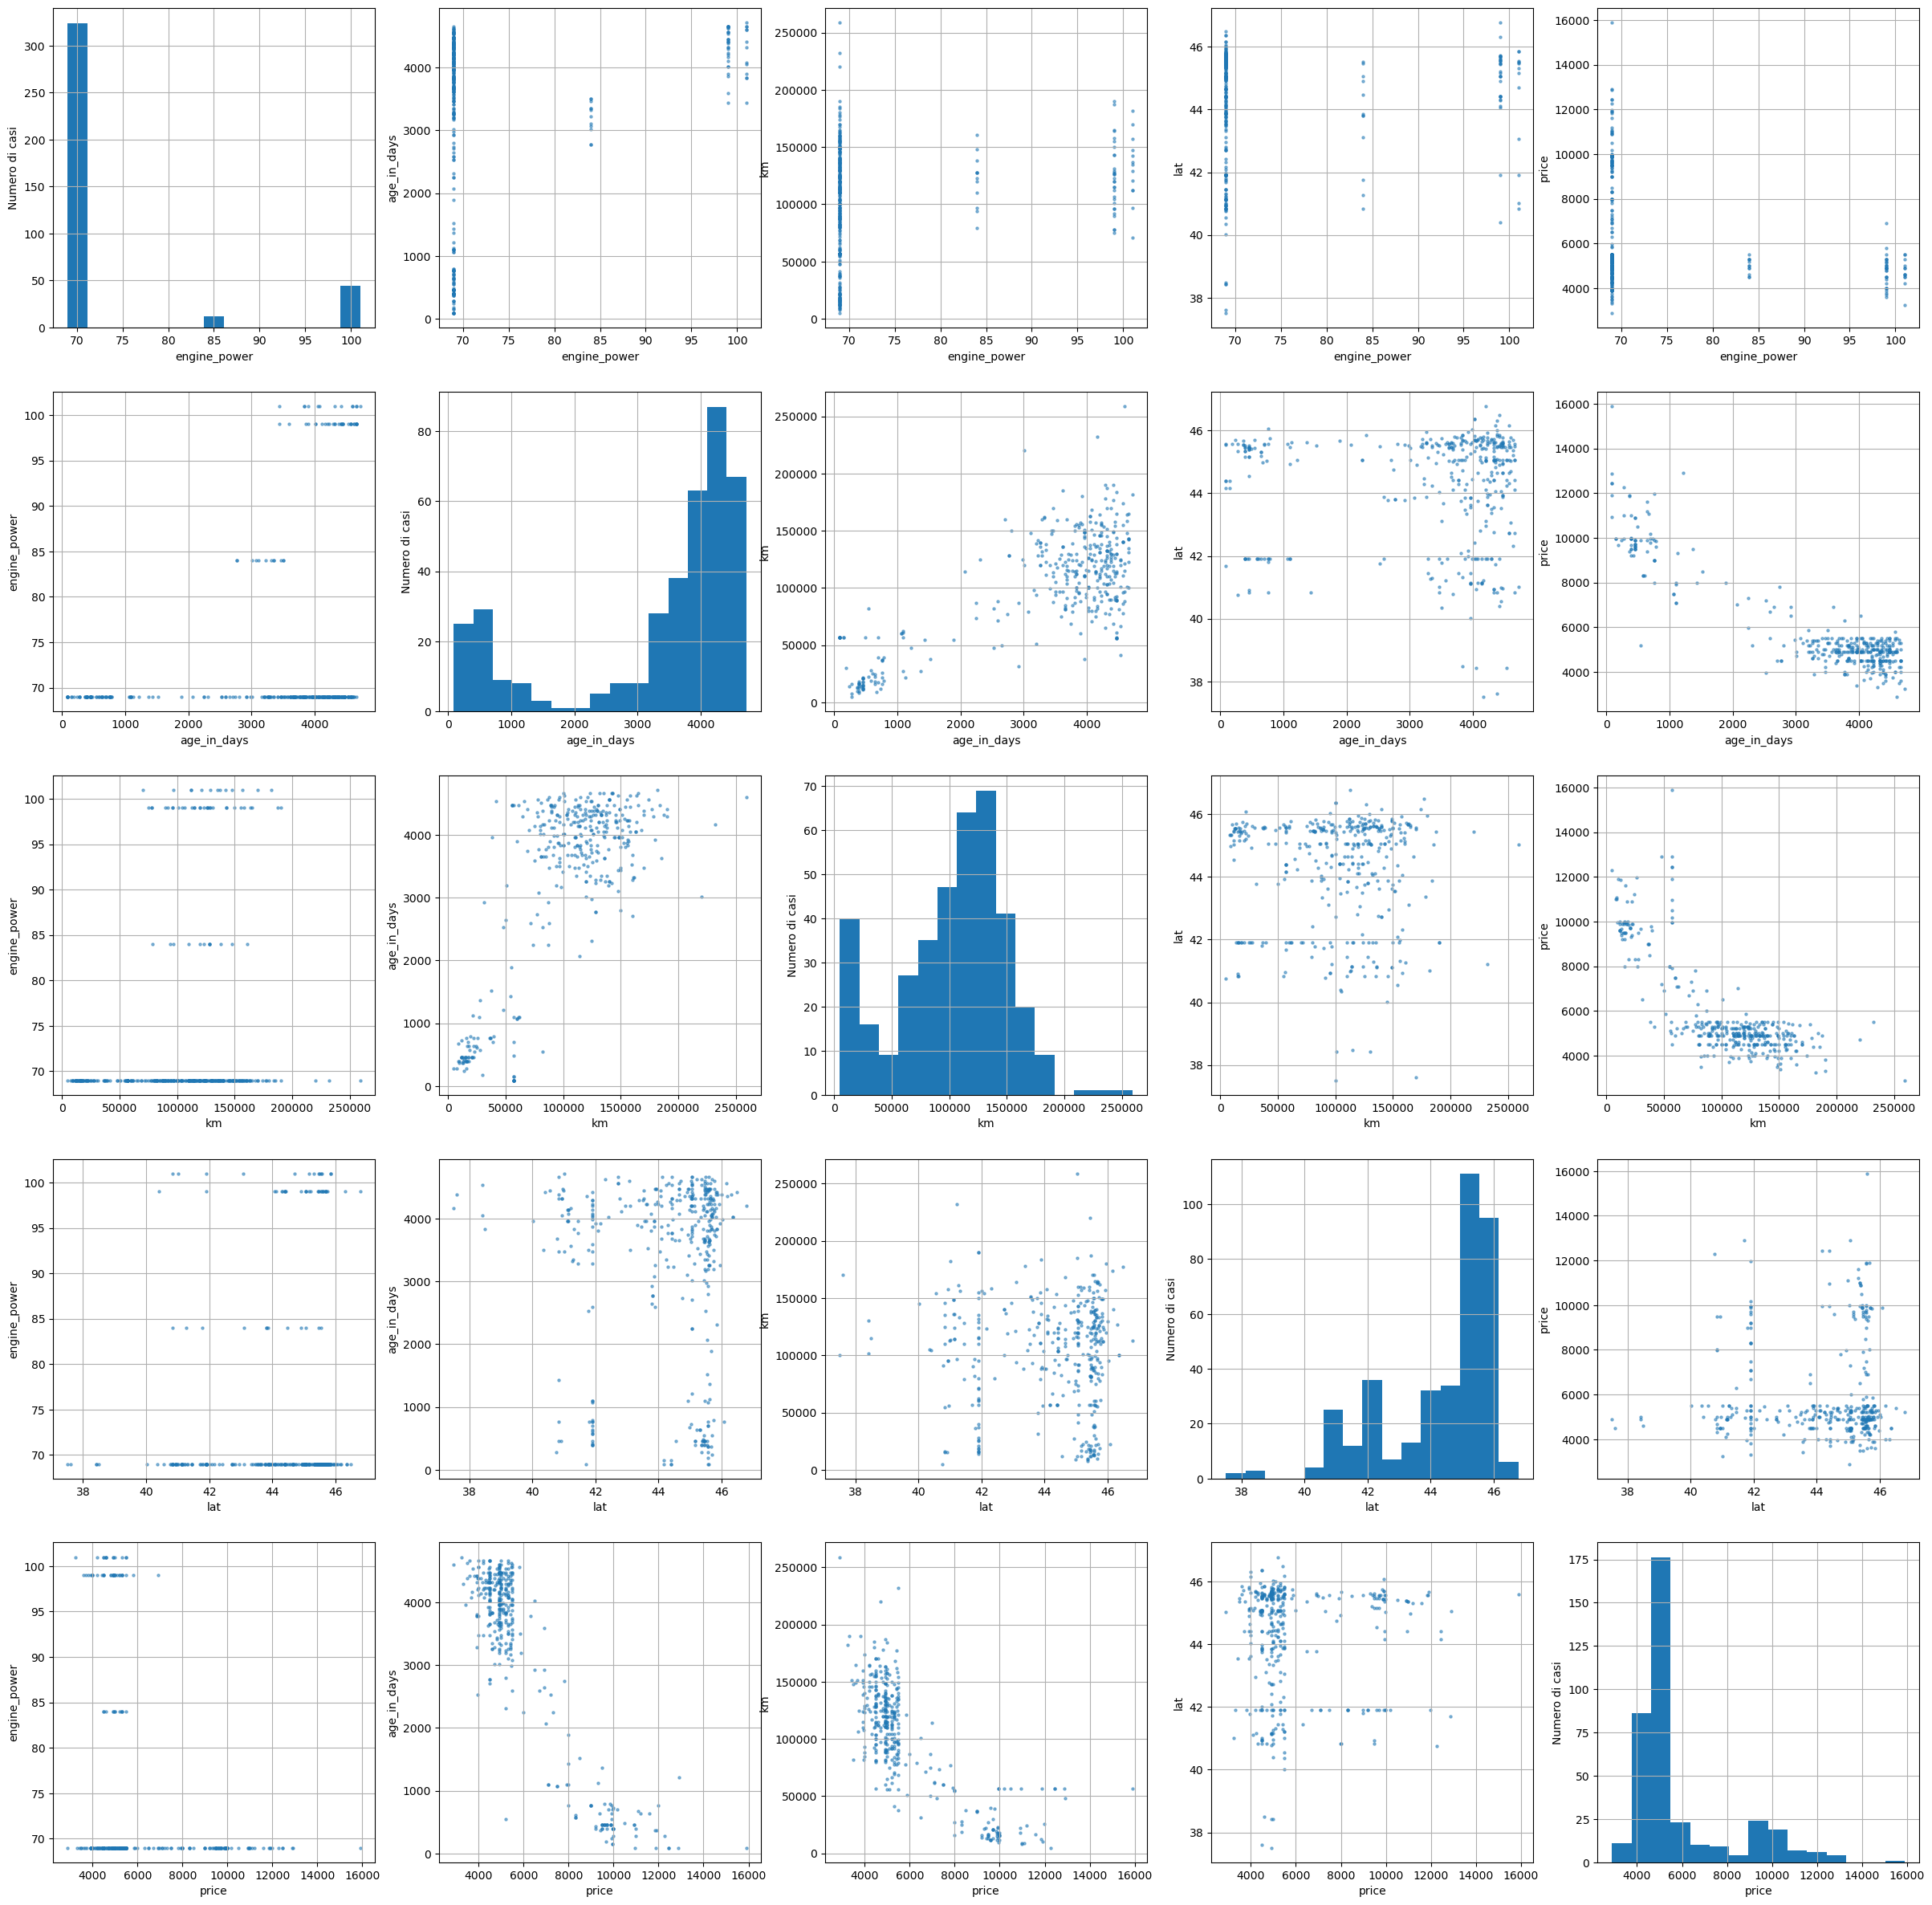

In [6]:
fig, axs = plt.subplots(nrows=5, ncols=5, figsize = (30, 30))
for i, var1 in enumerate(nomi_colonne):
    for j, var2  in enumerate(nomi_colonne):
        if i != j:
            array1 = data[var1].to_numpy()
            array2 = data[var2].to_numpy()
            axs[i, j].scatter(array1, array2, alpha = 0.5, s = 5)
            axs[i, j].set_xlabel(var1)
            axs[i, j].set_ylabel(var2)
        else:
            axs[i, j].hist(data[var1].to_numpy(), bins = 15)
            axs[i, j].set_xlabel(var1)
            axs[i, j].set_ylabel("Numero di casi")
        axs[i, j].grid()
plt.show()

## Compito grafici completi

In [7]:
#Nomi modelli
model_list = data["model"].unique() #select distinct model from data

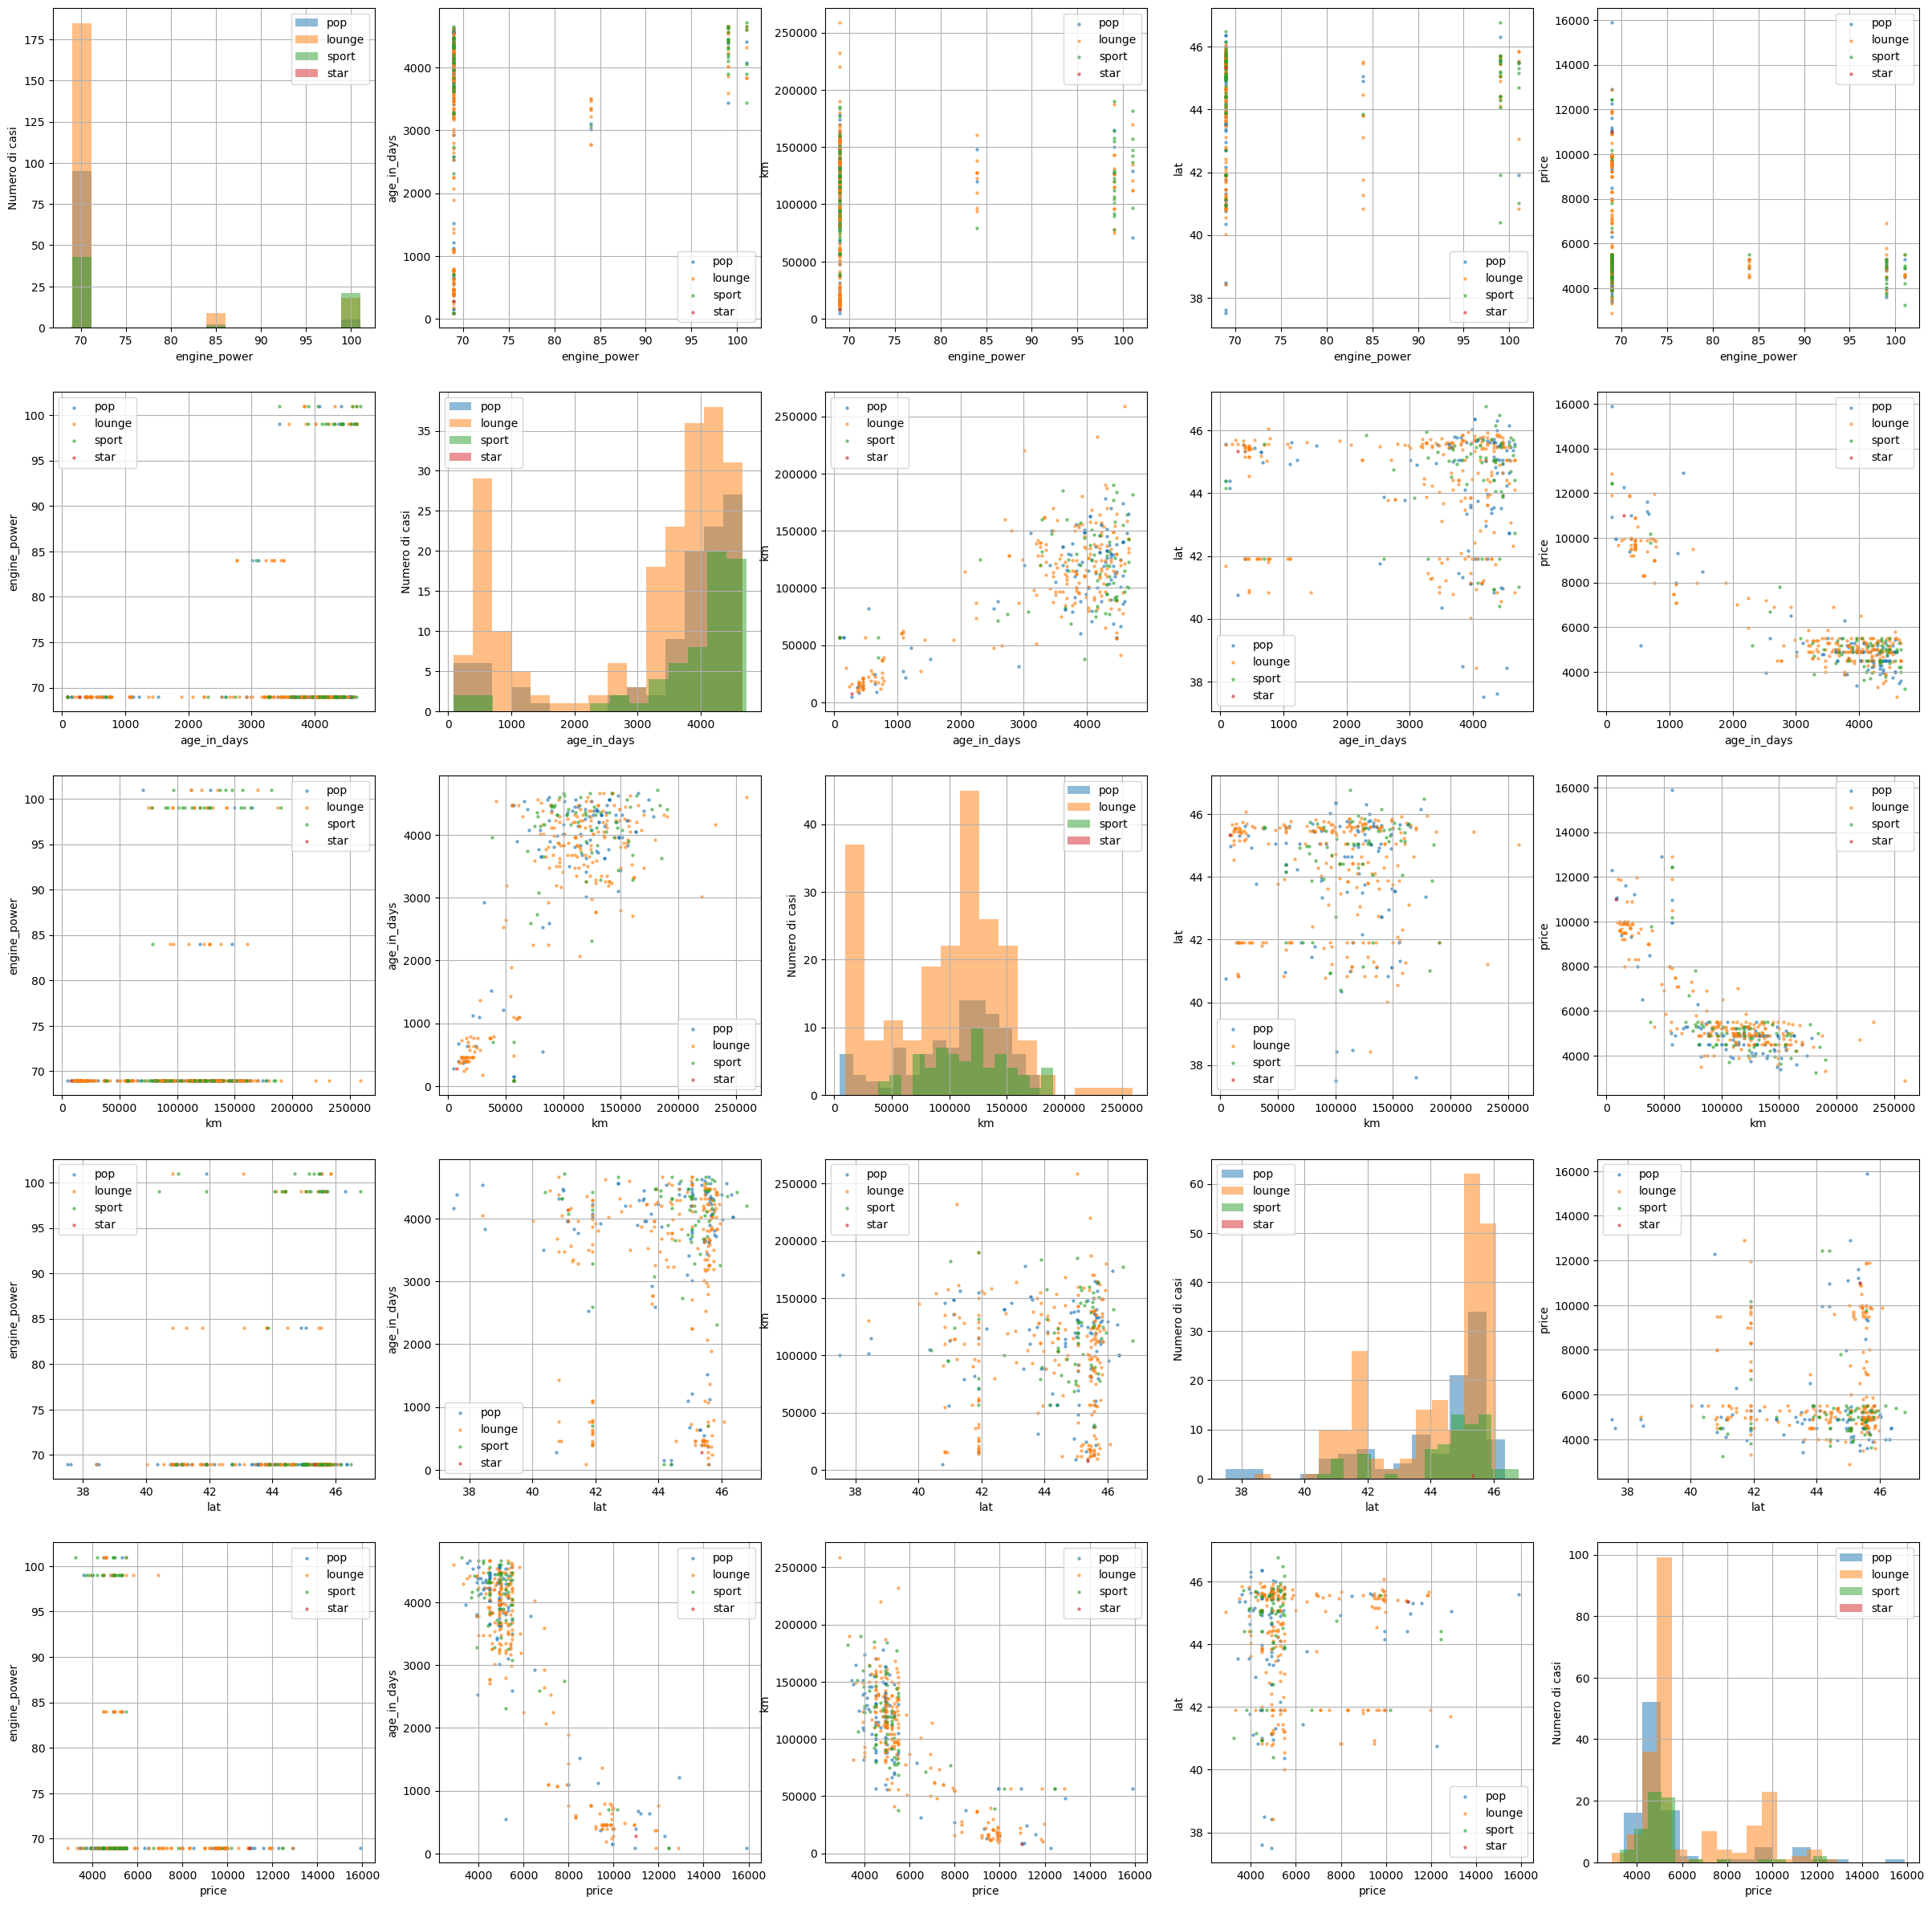

In [8]:
#Server selected quì perché filtro per bene, per modelli

fig, axs = plt.subplots(nrows=5, ncols=5, figsize = (30, 30))
for i, var1 in enumerate(nomi_colonne):
    for j, var2  in enumerate(nomi_colonne):
        for model in model_list:
            selected_data = data[data["model"] == model]
            if i != j:
                array1 = selected_data[var1].to_numpy()
                array2 = selected_data[var2].to_numpy()
                axs[i, j].scatter(array1, array2, alpha = 0.5, s = 5, label=model)
                axs[i, j].set_xlabel(var1)
                axs[i, j].set_ylabel(var2)
            else:
                axs[i, j].hist(selected_data[var1], alpha = 0.5, bins = 15, label=model)
                axs[i, j].set_xlabel(var1)
                axs[i, j].set_ylabel("Numero di casi")
        axs[i, j].legend()
        axs[i, j].grid()
plt.show()

## Cosa deduco da ogni grafico:

### ENGINE_POWER: (Maggioranza di auto motorizzazione 70kw, non tanta correlazione con altri dati)
1) Deduco dal primo grafico del primo tipo che di fiat 500 ci sono 3 motorizzazioni principali, quella con 70kw è la più popolare
(Questa popolarità influenza infatti tutti i grafici del tipo con engine_power) Un allestimento però è decisamente più acquistato di altri (lounge)
2) Per quanto riguarda l'età delle auto le più vendute sono quelle della motorizzazione 70kw con età intorno ai 4000 days
3) La maggior parte delle 500 sono vendute con dei kilometraggi 10/20 mila ai 50, poi c'è un piccolo taglio per un attimo e si riprende
da 70 mila fino a 180mila circa, è raro trovare 500 in vendita con più di 200k di km, per quanto riguarda le altre motorizzazioni non solo
sono più rare, ma sono tutte 100km < auto < 150km
4) Le 500 in vendite hanno per la maggior parte una latitudine maggiore di 40
5) La maggior parte dei prezzi li troviamo intorno ai 4000/5000 euro, al di sopra ce ne sono ma sono minori, in confronto

### AGE_IN_DAYS:
1) Come anche dedotto prima, la maggior parte delle 500 in vendita hanno più di 4000 giorni (O giù di lì) della motorizzazione 70kw
2) L'allestimento lounge è quello più in vendita, con 500 sia abbastanza nuove, che con l'età già citata prima, 4000 days
3) Giustamente in relazione ai km una macchina è più vecchia o più nuova, ma ci sono alcune auto anche relativamente nuove con parecchi kilometri
4) Si può notare come negli anni i modelli variano in latitudine, con la maggioranza di quelle vendute dai 44 ai 46 e più
5) Il prezzo ovviamente è collegato anche con l'età, più l'auto è vecchia meno la si vorrà comprare, con la maggioranza che hanno un prezzo simile
ci sono poche eccezioni

### KM:
1) Le 500 vendute hanno per lo più kilometraggi simili, che si concentrano fino ad arrivare intorno ai 170k, sempre con le 3 motorizzazioni di cui
la 70 è la più in vendità
2) Le 500 in vendita hanno i propri km in relazione con l'età, più è vecchia più ha kilometri
3) C'è una grande offerta di 500 lounge con pochi o tanti kilometri, mentre c'è una piccola parte di 500 pop "quasi nuove"
4) La lat nei kilometraggi è molto dispersa, ma una gran parte si trova intorno ai 100k - 150k dove la latitudine sembra essere maggiore
5) Meno kilometri hanno le 500 più il prezzo è alto, però avere più kilometri non significa che costa di meno!

### LAT:
1) Per le varie motorizzazioni la lat rimane perlomeno la stessa, diferisce da motorizzazione a motorizzazione (Inoltre anche nella stessa ci sono state diverse versioni di latitudine)
2) Viene reso più visibile come più è vecchia una 500 più la sua lat è maggiore, o èuò esserlo
3) C'è una relazione simile in questo punto, come al punto precedente, per quanto sembri che la lat più prominente sia intorno al valore 42 e 46
4) Visto che c'è maggioranza di lounge in altri campi non mi sorprende che anche quì i numeri di casi di latitudine è prevalentemente di lounge, intorno ai valori già accenati (da 42 a 46)
5) i prezzi da 4000 a 6000 hanno una maggioranza di lat che si concentra da 44 a 46, con alcuni casi rari di prezzi più alti con latitudine simile

### Price:
1) Il prezzo ha una sua media ma ci sono diversi esemplari anche parecchio costosi (Motorizzazione 70kw) le altre hanno meno disponibilità
2) La maggior parte di 500 con età simile (sui 4000) hanno anche prezzo simile (sui 5000), con poche ma non pochissime che vanno anche a costare sui diecimila (Esemplari più belli e ben tenuti probabilmente)
3) all'aumentare dei km non per forza il prezzo aumenta, ci sono diverse macchine con kilometri bassi che costano parecchio
4) Le diverse lat hanno prezzi che stanno per la maggior parte da quelle che sono maggiormente in vendita, con alcune che si alzano di prezzo (Probabilmente riferendosi ad altri tratti come km basso)
5) Lounge è il modello di 500 più presente, con la maggior parte dei prezzi intorno alla media, ma anche pop e sport sono disponibili a prezzi contenuti


## FUNZIONE PER FARE SCATTER O HISTOGRAMMA

In [42]:
def disegnaGrafico(x_name, y_name, data, cat_name, ax):
    lista = data[cat_name].unique()
    if x_name == y_name:
        for elemento in lista:
            selected_data = data[data[cat_name]== elemento]
            ax.hist(selected_data[x_name], alpha = 0.5, bins = 15, label=elemento)
            ax.set_xlabel(x_name)
            ax.set_ylabel("Numero di casi")
    else:
        for elemento in lista:
            selected_data = data[data[cat_name]== elemento]
            ax.scatter(selected_data[x_name], selected_data[y_name], alpha = 0.5, label=elemento)
            ax.set_xlabel(x_name)
            ax.set_ylabel(y_name)
    ax.legend()
    ax.grid()

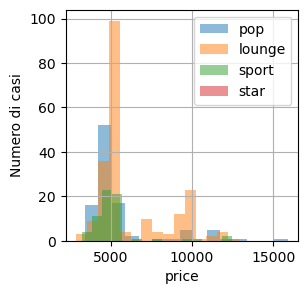

In [44]:
fig, ax = plt.subplots(figsize = (3, 3))
disegnaGrafico("price", "price", data, "model", ax)
plt.show()

## Così invece faccio un grafico che gestisce anche la questione di riconoscere quante colonne ha il grafico 

In [45]:
def analisiGrafica(data, cat_name):
    nomi_colonne = [col for col in data.columns if col != cat_name]
    
    n_vars = len(nomi_colonne)
    fig, axs = plt.subplots(nrows=n_vars, ncols=n_vars, figsize=(40, 40))
    
    for i, var1 in enumerate(nomi_colonne):
        for j, var2 in enumerate(nomi_colonne):
            disegnaGrafico(var1, var2, data, cat_name, axs[i, j])
    
    plt.show()

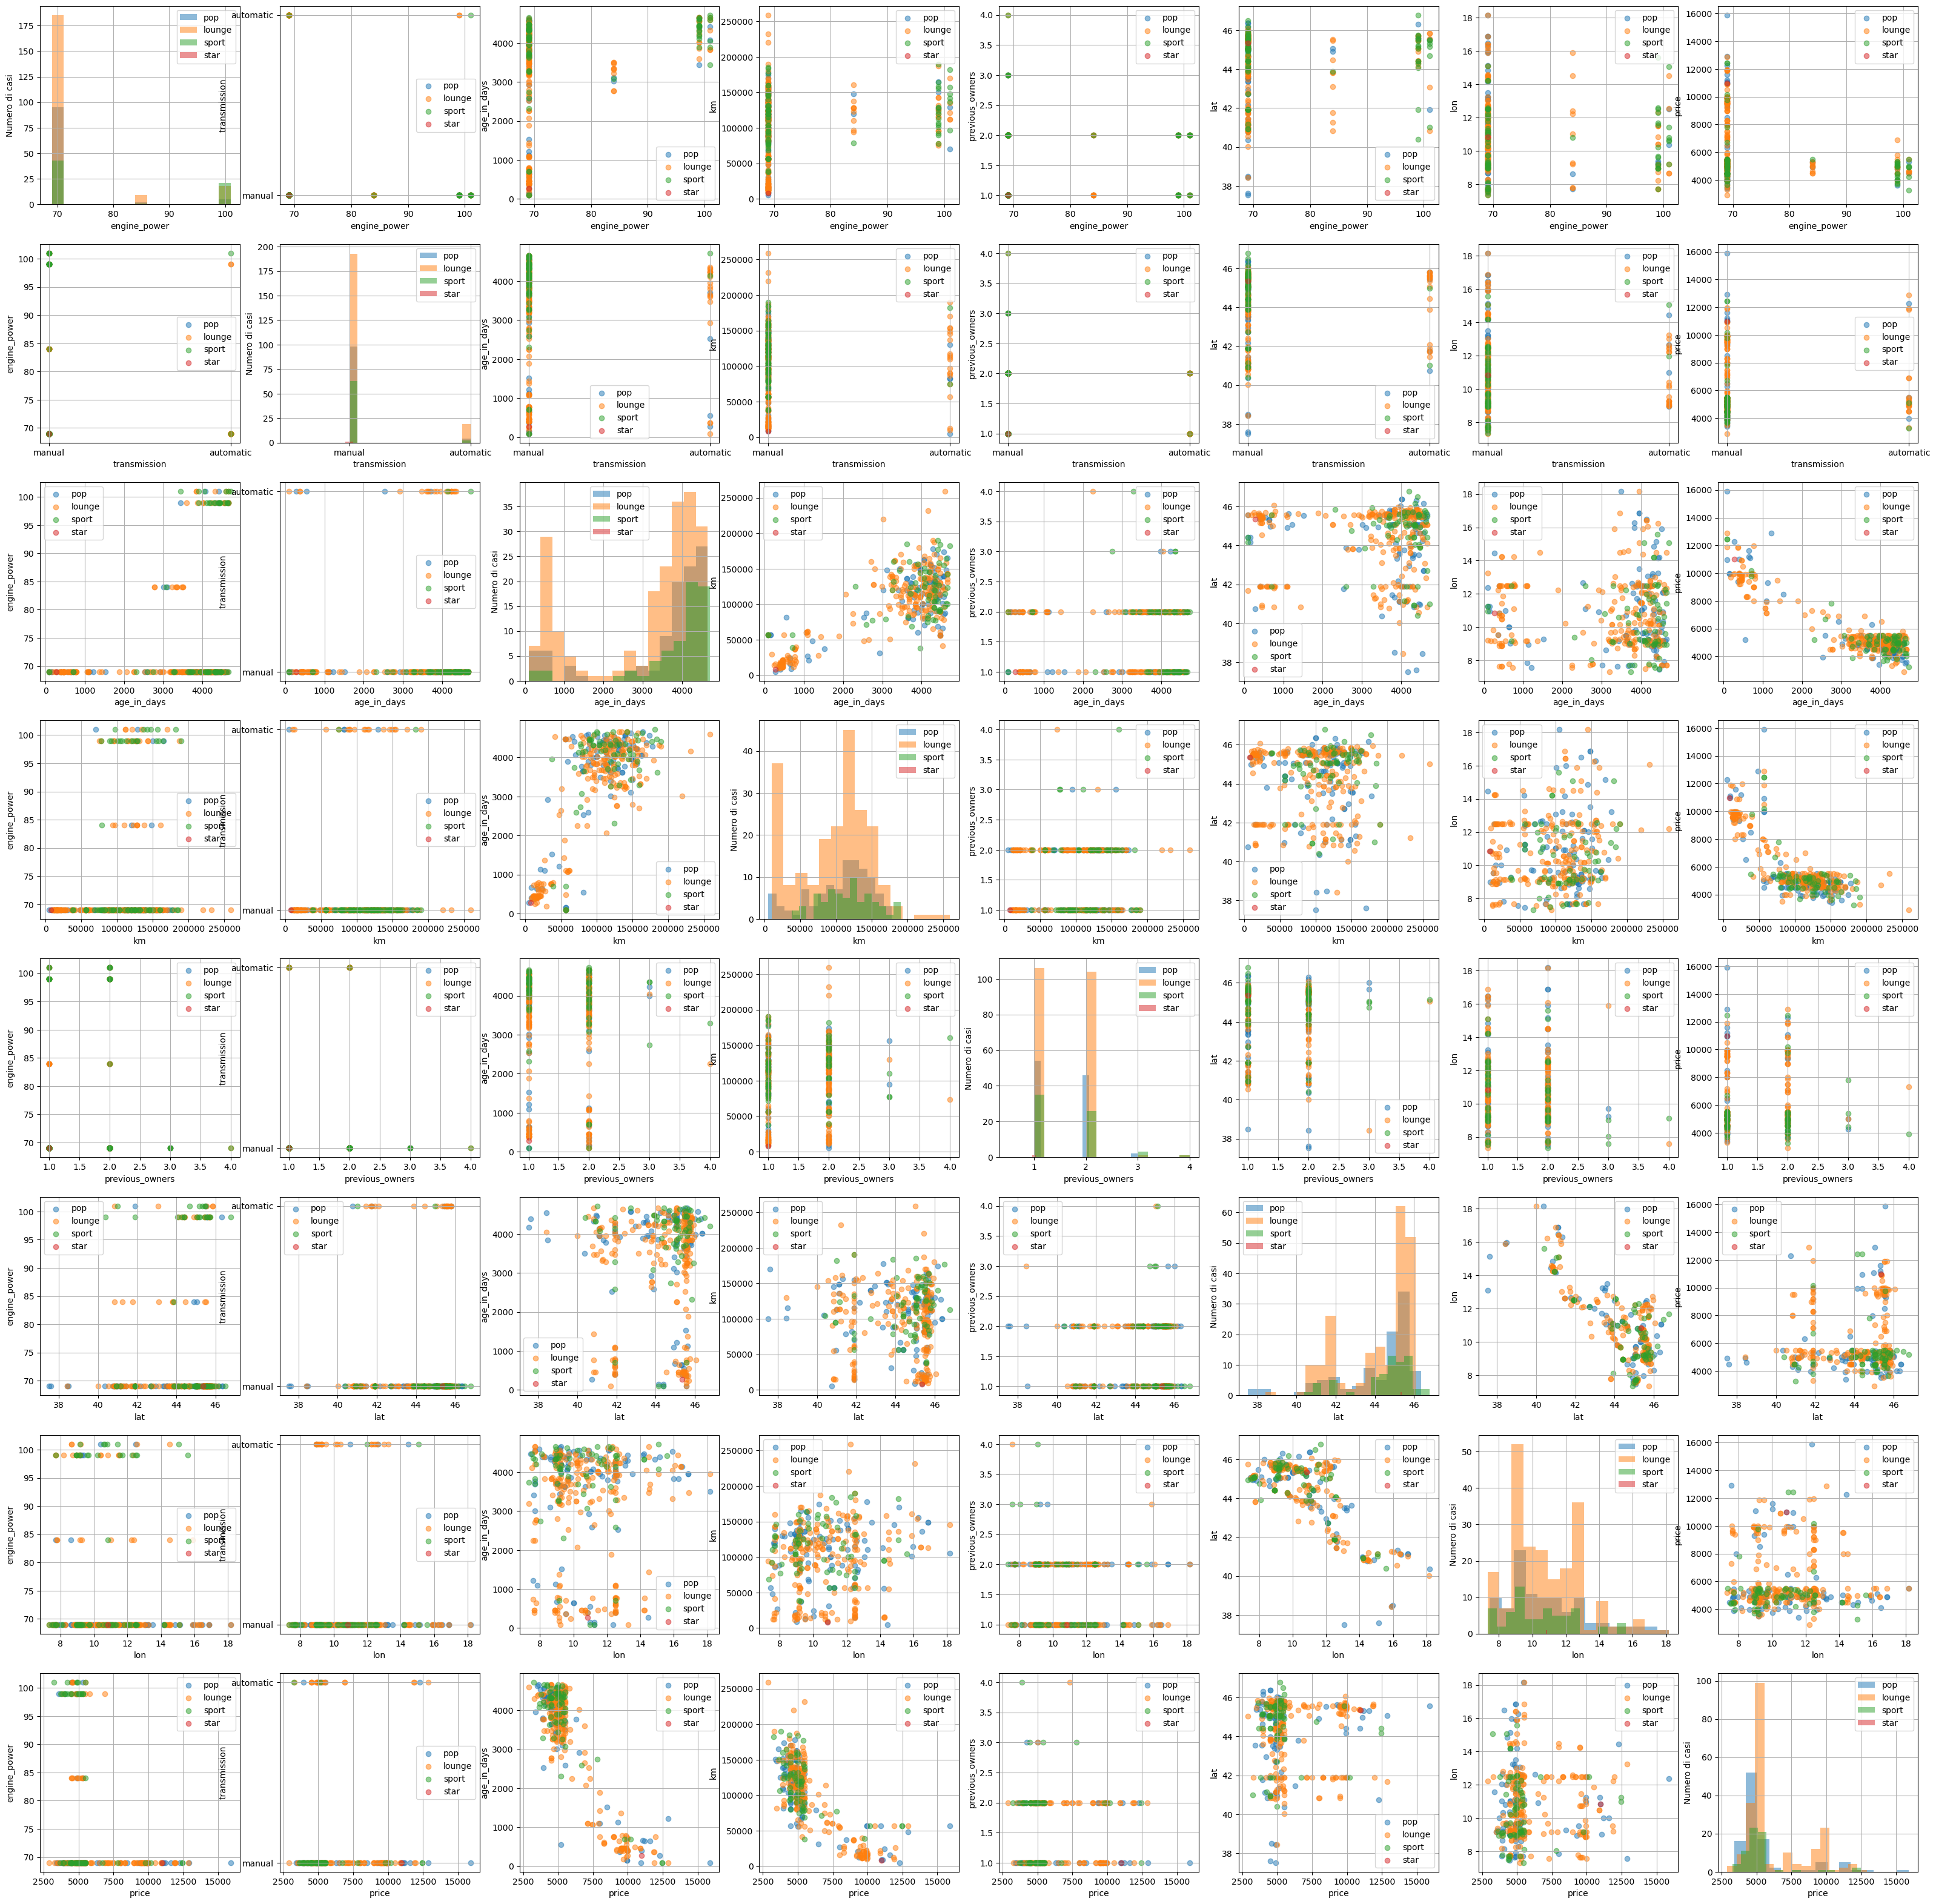

In [46]:
analisiGrafica(data, "model")